Dataset Loaded!
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596

Movie names loaded!

Matrix Shape: (943, 1682)

SVD Completed!

Prediction Done!

RMSE: 1.8533

🎯 Top Recommendations for User 0:

E.T. the Extra-Terrestrial (1982) → ⭐ 3.51
Batman (1989) → ⭐ 3.1
Dave (1993) → ⭐ 2.97
One Flew Over the Cuckoo's Nest (1975) → ⭐ 2.75
True Lies (1994) → ⭐ 2.61


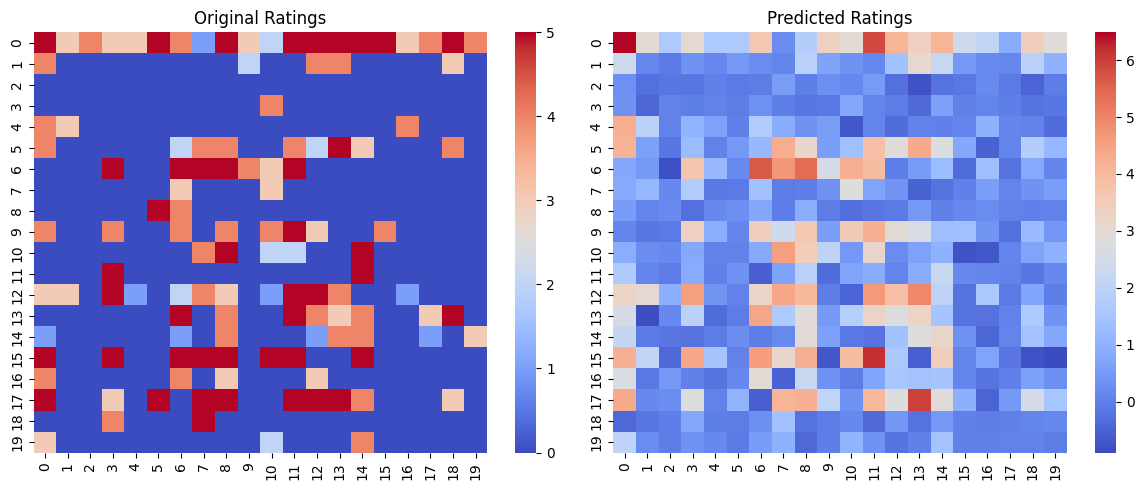

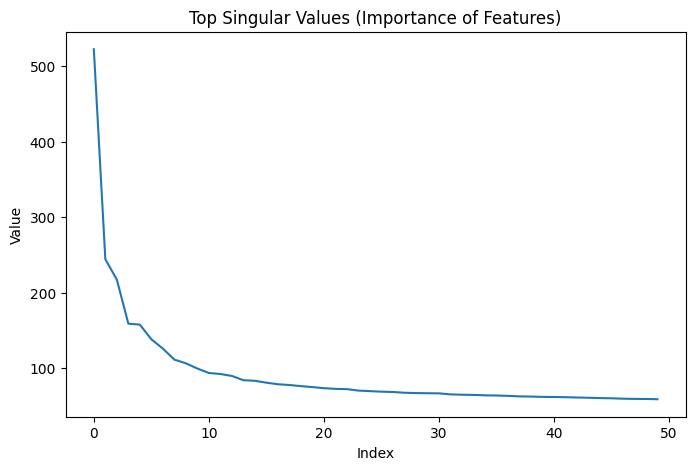

In [1]:
# =========================================
# 🎬 Movie Recommendation System using SVD
# (Real Dataset + Movie Names + Visualization)
# =========================================

# STEP 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(suppress=True)

# =========================================
# STEP 2: Load Dataset
# =========================================

df = pd.read_csv(
    "data/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

print("Dataset Loaded!")
print(df.head())

# =========================================
# STEP 3: Load Movie Names
# =========================================
movie_df = pd.read_csv(
    "data/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1],
    names=["item_id", "title"]
)

movie_dict = dict(zip(movie_df.item_id, movie_df.title))

print("\nMovie names loaded!")

# =========================================
# STEP 4: Create User-Item Matrix
# =========================================
user_item_matrix = df.pivot_table(
    index="user_id",
    columns="item_id",
    values="rating"
)

ratings = user_item_matrix.fillna(0).values

print("\nMatrix Shape:", ratings.shape)

# =========================================
# STEP 5: Apply SVD
# =========================================
user_means = np.mean(ratings, axis=1, keepdims=True)
ratings_centered = ratings - user_means

U, S, Vt = np.linalg.svd(ratings_centered, full_matrices=False)

k = 50
U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]

print("\nSVD Completed!")

# =========================================
# STEP 6: Reconstruct Matrix
# =========================================
predicted_ratings = (U_k @ S_k @ Vt_k) + user_means

print("\nPrediction Done!")

# =========================================
# STEP 7: Evaluate (RMSE)
# =========================================
mask = ratings > 0
rmse = np.sqrt(np.mean((ratings[mask] - predicted_ratings[mask]) ** 2))

print(f"\nRMSE: {rmse:.4f}")

# =========================================
# STEP 8: Recommendation Function
# =========================================
def recommend_movies(ratings, predicted_ratings, user_index, top_n=5):
    original = ratings[user_index]
    predicted = predicted_ratings[user_index]

    recommendations = np.argsort(-predicted)

    result = []
    for i in recommendations:
        if original[i] == 0:
            result.append((i, round(predicted[i], 2)))
        if len(result) >= top_n:
            break

    return result

# =========================================
# STEP 9: Get Recommendations (WITH NAMES)
# =========================================
user_index = 0

recs = recommend_movies(ratings, predicted_ratings, user_index)

print(f"\n🎯 Top Recommendations for User {user_index}:\n")

for movie, rating in recs:
    movie_id = movie + 1  # dataset is 1-indexed
    movie_name = movie_dict.get(movie_id, "Unknown Movie")
    print(f"{movie_name} → ⭐ {rating}")

# =========================================
# STEP 10: Visualization
# =========================================

# 🔥 Heatmap (Before vs After)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(ratings[:20, :20], cmap="coolwarm")
plt.title("Original Ratings")

plt.subplot(1, 2, 2)
sns.heatmap(predicted_ratings[:20, :20], cmap="coolwarm")
plt.title("Predicted Ratings")

plt.tight_layout()
plt.show()

# 🔥 Singular Values Plot
plt.figure(figsize=(8, 5))
plt.plot(S[:50])
plt.title("Top Singular Values (Importance of Features)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

# =========================================
# 🎉 DONE
# =========================================

# This project demonstrates:
# - SVD (A = UΣVᵀ)
# - Dimensionality reduction
# - Matrix reconstruction
# - RMSE evaluation
# - Real-world recommendation system
# - Visualization of linear algebra concepts